# Avaliação visual do pipeline em bancos CCTA externos

Esta análise compara as avaliações visuais em resoluções **mid** e **high** no MM-WHS e no OrCaScore. As classificações descrevem a aparência dos artefatos, não uma validação clínica. Os percentuais incluem os exames `Não avaliável` no denominador.

O Dice da aorta usa o ground truth disponível apenas nos 20 exames CT de treino do MM-WHS. O conjunto de teste não entra nessa análise quantitativa.

In [1]:
# ruff: noqa: E402
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file()
)
sys.path.insert(0, str(REPO_ROOT / "src"))

from utils.project.external_ccta_results import load_mmwhs_train_aorta_dice
from utils.project.external_visual_assessment import (
    AORTA_ARTERY_STATUS_ORDER,
    OSTIA_STATUS_ORDER,
    attach_assessment_subsets,
    load_assessment_subset_lookup,
    load_external_visual_assessments,
    summarize_visual_status,
    summarize_visual_overview,
)

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

## Configuração e carregamento

In [2]:
EXTERNAL_RESULTS_ROOT = Path(
    os.environ.get(
        "EXTERNAL_CCTA_RESULTS_ROOT",
        "/media/matheus/HD/Results_dataset_ccta",
    )
)
RUN_DIRS = {
    "mid": {
        "MM-WHS": EXTERNAL_RESULTS_ROOT / "mmwhs/mid_res/2026-09-22_18-51-28",
        "OrCaScore": EXTERNAL_RESULTS_ROOT / "orcascore/mid_res/2026-09-19_10-23-50",
    },
    "high": {
        "MM-WHS": EXTERNAL_RESULTS_ROOT / "mmwhs/high_res/2026-09-22_17-47-45",
        "OrCaScore": EXTERNAL_RESULTS_ROOT / "orcascore/high_res/2026-09-22_19-12-41",
    },
}
DATASET_ORDER = ["MM-WHS", "OrCaScore"]
COHORT_ORDER = [*DATASET_ORDER, "Geral"]
STATUS_COLORS = {
    "Adequada": "#22C55E",
    "Ambos adequados": "#22C55E",
    "Parcial": "#EAB308",
    "Um adequado": "#EAB308",
    "Inadequada": "#EF4444",
    "Inadequados": "#EF4444",
    "Não detectada": "#F97316",
    "Não detectados": "#F97316",
    "Não avaliável": "#9CA3AF",
}
RESOLUTION_COLORS = {"mid": "#4C78A8", "high": "#F28E2B"}

subset_lookup = load_assessment_subset_lookup(
    {
        dataset: [
            RUN_DIRS[resolution][dataset] / "numeric/results_all.csv"
            for resolution in RUN_DIRS
        ]
        for dataset in DATASET_ORDER
    }
)
assessments = {
    resolution: attach_assessment_subsets(
        load_external_visual_assessments(
            {
                dataset: run_dir / "visual/avaliacao_visual.xlsx"
                for dataset, run_dir in run_dirs.items()
            }
        ),
        subset_lookup,
    )
    for resolution, run_dirs in RUN_DIRS.items()
}

In [3]:
def show_general_results(resolution):
    result = summarize_visual_overview(assessments[resolution], DATASET_ORDER)
    labels = {
        "dataset": "Banco",
        "subset": "Conjunto",
        "exam_count": "Exames",
        "aorta_adequate_count": "Aorta (n)",
        "aorta_adequate_percent": "Aorta (%)",
        "ostia_adequate_count": "Óstios (n)",
        "ostia_adequate_percent": "Óstios (%)",
        "artery_adequate_count": "Artéria (n)",
        "artery_adequate_percent": "Artéria (%)",
    }
    split_labels = {"train": "Treino", "test": "Teste", "total": "Total"}
    table = result.rename(columns=labels).copy()
    table["Conjunto"] = table["Conjunto"].map(split_labels)
    display(table.set_index(["Banco", "Conjunto"]).round(1))

    plotted = result.loc[result["dataset"].ne("Geral")].copy()
    plotted["Grupo"] = plotted["dataset"] + " · " + plotted["subset"].map(split_labels)
    rates = plotted.set_index("Grupo")[
        [
            "aorta_adequate_percent",
            "ostia_adequate_percent",
            "artery_adequate_percent",
        ]
    ].rename(
        columns={
            "aorta_adequate_percent": "Aorta",
            "ostia_adequate_percent": "Óstios",
            "artery_adequate_percent": "Artéria",
        }
    )
    ax = rates.plot(
        kind="bar",
        figsize=(11, 4.5),
        color=["#4C78A8", "#59A14F", "#F28E2B"],
        edgecolor="black",
        rot=15,
    )
    ax.set(
        xlabel="",
        ylabel="Exames com resultado totalmente adequado (%)",
        ylim=(0, 100),
        title=f"Resultados totalmente adequados — {resolution}",
    )
    ax.legend(title="Etapa", frameon=False)
    plt.show()
    return result


def show_stage_results(resolution, column, status_order, title):
    summary = summarize_visual_status(
        assessments[resolution], column, status_order, DATASET_ORDER
    )
    compact = summary.assign(
        resultado=summary.apply(
            lambda row: f"{row['count']} ({row['percent']:.1f}%)", axis=1
        )
    ).pivot(index="dataset", columns="status", values="resultado")
    display(compact.reindex(index=COHORT_ORDER, columns=status_order))

    percentages = summary.pivot(
        index="dataset", columns="status", values="percent"
    ).reindex(index=COHORT_ORDER, columns=status_order)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    left = np.zeros(len(percentages))
    for status in status_order:
        values = percentages[status].to_numpy(dtype=float)
        bars = ax.barh(
            percentages.index,
            values,
            left=left,
            color=STATUS_COLORS[status],
            label=status,
        )
        for bar, value in zip(bars, values, strict=True):
            if value >= 5:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )
        left += values
    ax.set(
        xlabel="Exames (%)", ylabel="", title=f"{title} — {resolution}", xlim=(0, 100)
    )
    ax.invert_yaxis()
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
    plt.show()
    return summary

## 1. Resultados gerais

A análise inclui todos os exames avaliados visualmente. No OrCaScore high, o TEV2P6 pertence ao teste conforme o CSV mid, embora esteja ausente do CSV high.

### Mid resolution

Exames  Aorta (n)  Aorta (%)  Óstios (n)  Óstios (%)  \
Banco     Conjunto                                                         
MM-WHS    Treino        20         15       75.0           8        40.0   
          Teste         40         23       57.5          20        50.0   
OrCaScore Treino        32         21       65.6          15        46.9   
          Teste         40         24       60.0          18        45.0   
Geral     Treino        52         36       69.2          23        44.2   
          Teste         80         47       58.8          38        47.5   
          Total        132         83       62.9          61        46.2   

                    Artéria (n)  Artéria (%)  
Banco     Conjunto                            
MM-WHS    Treino              3         15.0  
          Teste              12         30.0  
OrCaScore Treino             10         31.2  
          Teste              11         27.5  
Geral     Treino             13         25.0  
          Teste              23         28.8  
          Total              36         27.3

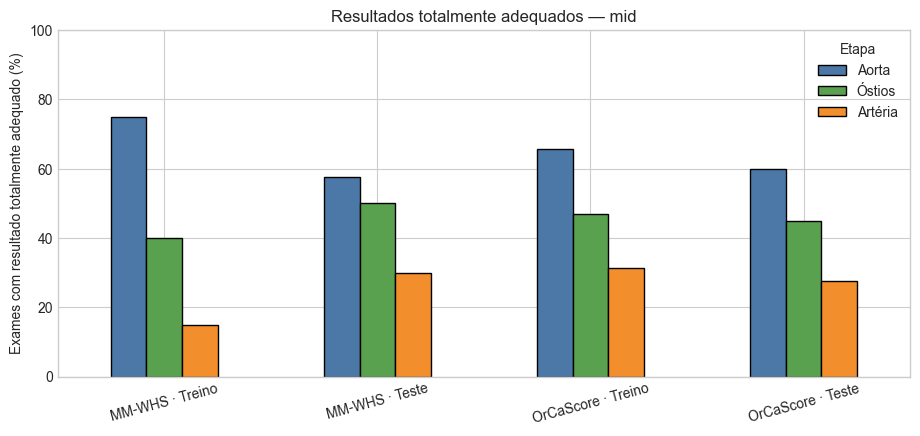

In [4]:
general_mid = show_general_results("mid")

### High resolution

Exames  Aorta (n)  Aorta (%)  Óstios (n)  Óstios (%)  \
Banco     Conjunto                                                         
MM-WHS    Treino        20         18       90.0          16        80.0   
          Teste         40         28       70.0          16        40.0   
OrCaScore Treino        32         23       71.9          13        40.6   
          Teste         40         25       62.5          25        62.5   
Geral     Treino        52         41       78.8          29        55.8   
          Teste         80         53       66.2          41        51.2   
          Total        132         94       71.2          70        53.0   

                    Artéria (n)  Artéria (%)  
Banco     Conjunto                            
MM-WHS    Treino              5         25.0  
          Teste               6         15.0  
OrCaScore Treino              4         12.5  
          Teste              12         30.0  
Geral     Treino              9         17.3  
          Teste              18         22.5  
          Total              27         20.5

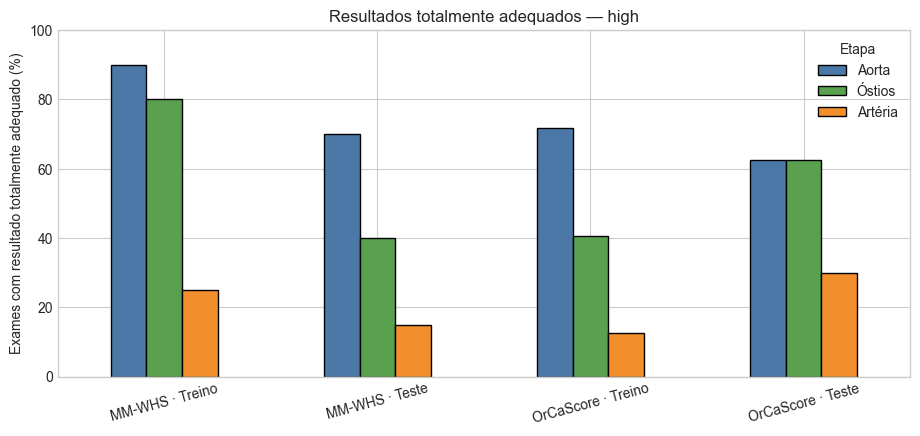

In [5]:
general_high = show_general_results("high")

## 2. Aorta

### Mid resolution

status,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,
MM-WHS,38 (63.3%),7 (11.7%),9 (15.0%),6 (10.0%),0 (0.0%)
OrCaScore,45 (62.5%),9 (12.5%),5 (6.9%),9 (12.5%),4 (5.6%)
Geral,83 (62.9%),16 (12.1%),14 (10.6%),15 (11.4%),4 (3.0%)


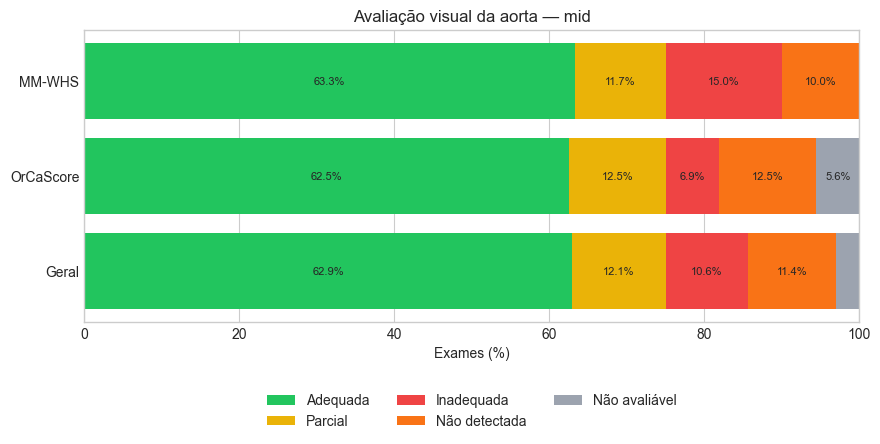

In [6]:
aorta_mid = show_stage_results(
    "mid", "aorta_result", AORTA_ARTERY_STATUS_ORDER, "Avaliação visual da aorta"
)

### High resolution

status,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,
MM-WHS,46 (76.7%),6 (10.0%),8 (13.3%),0 (0.0%),0 (0.0%)
OrCaScore,48 (66.7%),4 (5.6%),5 (6.9%),2 (2.8%),13 (18.1%)
Geral,94 (71.2%),10 (7.6%),13 (9.8%),2 (1.5%),13 (9.8%)


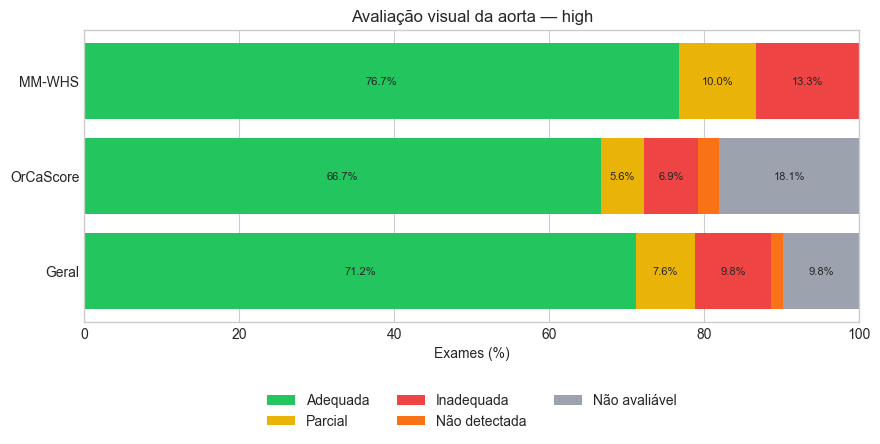

In [7]:
aorta_high = show_stage_results(
    "high", "aorta_result", AORTA_ARTERY_STATUS_ORDER, "Avaliação visual da aorta"
)

## 3. Óstios

### Mid resolution

status,Ambos adequados,Um adequado,Inadequados,Não detectados,Não avaliável
dataset,,,,,
MM-WHS,28 (46.7%),9 (15.0%),16 (26.7%),0 (0.0%),7 (11.7%)
OrCaScore,33 (45.8%),9 (12.5%),6 (8.3%),0 (0.0%),24 (33.3%)
Geral,61 (46.2%),18 (13.6%),22 (16.7%),0 (0.0%),31 (23.5%)


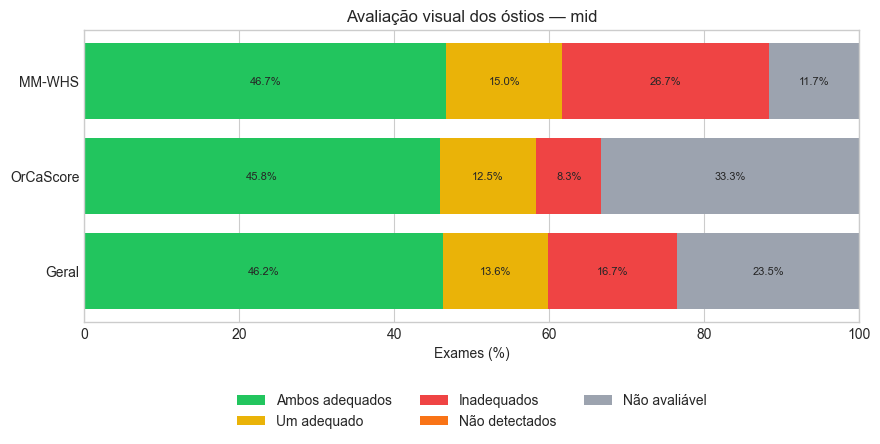

In [8]:
ostia_mid = show_stage_results(
    "mid", "ostia_result", OSTIA_STATUS_ORDER, "Avaliação visual dos óstios"
)

### High resolution

status,Ambos adequados,Um adequado,Inadequados,Não detectados,Não avaliável
dataset,,,,,
MM-WHS,32 (53.3%),11 (18.3%),16 (26.7%),0 (0.0%),1 (1.7%)
OrCaScore,38 (52.8%),8 (11.1%),6 (8.3%),0 (0.0%),20 (27.8%)
Geral,70 (53.0%),19 (14.4%),22 (16.7%),0 (0.0%),21 (15.9%)


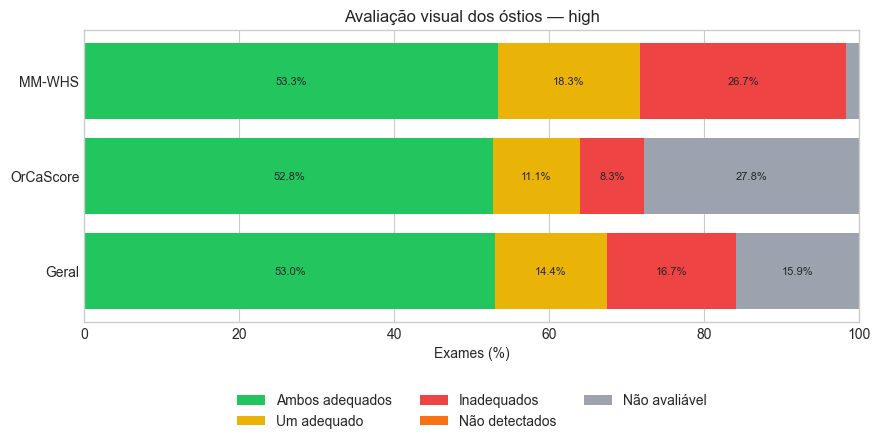

In [9]:
ostia_high = show_stage_results(
    "high", "ostia_result", OSTIA_STATUS_ORDER, "Avaliação visual dos óstios"
)

## 4. Artéria

### Mid resolution

status,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,
MM-WHS,15 (25.0%),20 (33.3%),16 (26.7%),2 (3.3%),7 (11.7%)
OrCaScore,21 (29.2%),20 (27.8%),5 (6.9%),3 (4.2%),23 (31.9%)
Geral,36 (27.3%),40 (30.3%),21 (15.9%),5 (3.8%),30 (22.7%)


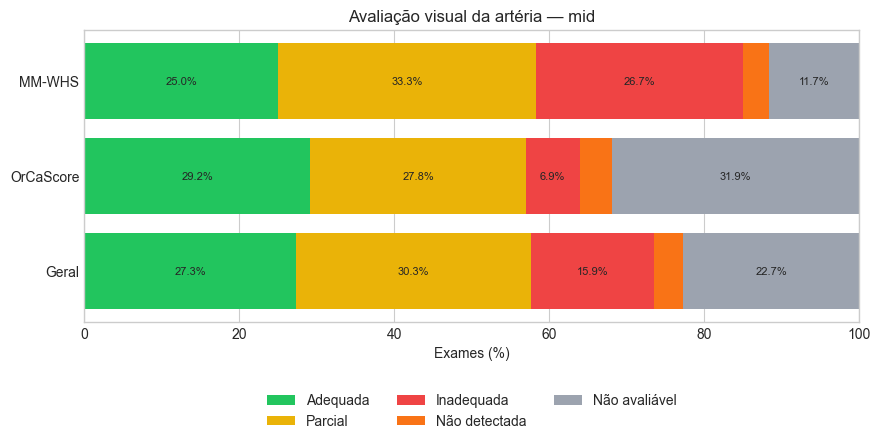

In [10]:
artery_mid = show_stage_results(
    "mid", "artery_result", AORTA_ARTERY_STATUS_ORDER, "Avaliação visual da artéria"
)

### High resolution

status,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,
MM-WHS,11 (18.3%),29 (48.3%),17 (28.3%),2 (3.3%),1 (1.7%)
OrCaScore,16 (22.2%),28 (38.9%),5 (6.9%),1 (1.4%),22 (30.6%)
Geral,27 (20.5%),57 (43.2%),22 (16.7%),3 (2.3%),23 (17.4%)


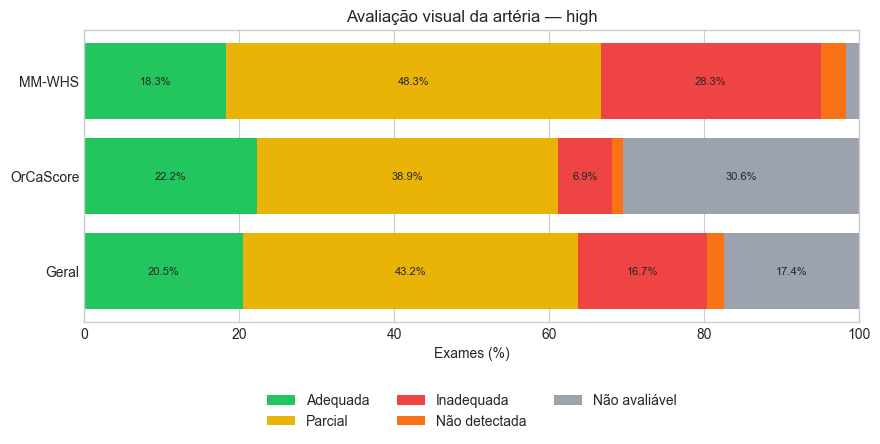

In [11]:
artery_high = show_stage_results(
    "high", "artery_result", AORTA_ARTERY_STATUS_ORDER, "Avaliação visual da artéria"
)

## 5. Dice da aorta no MM-WHS (treino)

O Dice é volumétrico e compara a máscara prevista com o rótulo `820` no volume processado completo. Apenas os 20 exames CT de treino têm ground truth compatível. Os 40 exames de teste permanecem fora da média; ausência de Dice não significa Dice zero. O Dice genérico de artéria coronária não é usado aqui.

In [12]:
dice_by_case = pd.DataFrame(
    {
        resolution: load_mmwhs_train_aorta_dice(
            RUN_DIRS[resolution]["MM-WHS"] / "numeric/results_all.csv"
        )
        for resolution in RUN_DIRS
    }
)
if dice_by_case.isna().any().any():
    raise ValueError(
        "Os runs mid e high não possuem o mesmo conjunto de exames de treino"
    )
dice_by_case.index.name = "Exame"
print(f"Exames pareados com Dice: {len(dice_by_case)}")

Exames pareados com Dice: 20


### Resultado geral

,count,mean,median,std,min,max
Resolução,,,,,,
mid,20.0,0.845,0.932,0.235,0.0,0.975
high,20.0,0.858,0.938,0.235,0.0,0.980


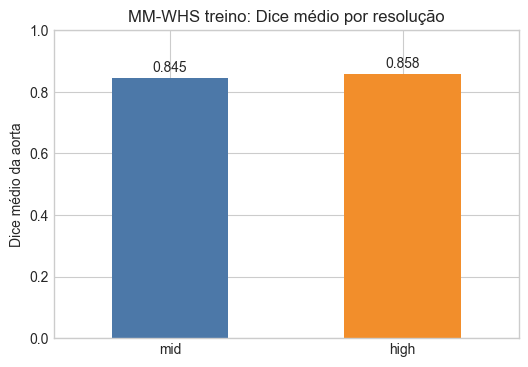

In [13]:
dice_overall = dice_by_case.agg(["count", "mean", "median", "std", "min", "max"]).T
dice_overall.index.name = "Resolução"
display(dice_overall.round(3))

ax = dice_overall["mean"].plot.bar(
    color=[RESOLUTION_COLORS[resolution] for resolution in dice_overall.index],
    figsize=(6, 4),
    ylim=(0, 1),
    rot=0,
)
ax.set(
    xlabel="",
    ylabel="Dice médio da aorta",
    title="MM-WHS treino: Dice médio por resolução",
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.3f}",
        ha="center",
    )
plt.show()

### Resultado por exame

O diagnóstico visual da aorta é mostrado separadamente para cada resolução.

In [14]:
visual_aorta = {}
for resolution in ("mid", "high"):
    visual = (
        assessments[resolution]
        .loc[lambda frame: frame["dataset"].eq("MM-WHS"), ["image_id", "aorta_result"]]
        .set_index("image_id")["aorta_result"]
    )
    missing = dice_by_case.index.difference(visual.index)
    if len(missing):
        raise ValueError(
            f"{resolution}: {len(missing)} exames com Dice sem avaliação visual da aorta: "
            f"{missing.tolist()}"
        )
    visual_aorta[resolution] = visual.reindex(dice_by_case.index)

dice_case_summary = pd.DataFrame(
    {
        "Dice mid": dice_by_case["mid"],
        "Aorta visual mid": visual_aorta["mid"],
        "Dice high": dice_by_case["high"],
        "Aorta visual high": visual_aorta["high"],
        "Delta Dice (high - mid)": dice_by_case["high"] - dice_by_case["mid"],
    }
)
display(dice_case_summary.round(4))

,Dice mid,Aorta visual mid,Dice high,Aorta visual high,Delta Dice (high - mid)
Exame,,,,,
ct_train_1001,0.9603,Adequada,0.8914,Adequada,-0.0689
ct_train_1002,0.0002,Inadequada,0.9425,Adequada,0.9423
ct_train_1003,0.9527,Adequada,0.9552,Adequada,0.0025
ct_train_1004,0.9412,Adequada,0.9803,Adequada,0.0391
ct_train_1005,0.9263,Adequada,0.9167,Adequada,-0.0096
ct_train_1006,0.9163,Adequada,0.9245,Adequada,0.0082
ct_train_1007,0.9338,Adequada,0.9436,Adequada,0.0099
ct_train_1008,0.9203,Adequada,0.9402,Adequada,0.0199
ct_train_1009,0.4381,Inadequada,0.8760,Adequada,0.4379
